<a href="https://colab.research.google.com/github/Lio72rga/Miner-a-de-Datos-2026/blob/main/Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio Sección 1 (EDA básico con clientes bancarios)**

In [1]:
import pandas as pd

# Crear DataFrame con los datos de clientes
df = pd.DataFrame({
    "Cliente":       [1, 2, 3, 4, 5],
    "Edad":          [25, 40, 35, 50, 30],
    "Salario":       [50000, 60000, 70000, 80000, 45000],
    "Estado_Cuenta": ["Pagado", "Moroso", "Pagado", "Moroso", "Pagado"]
})

df


,Cliente,Edad,Salario,Estado_Cuenta
0,1,25,50000,Pagado
1,2,40,60000,Moroso
2,3,35,70000,Pagado
3,4,50,80000,Moroso
4,5,30,45000,Pagado


**Histograma de la variable Edad**

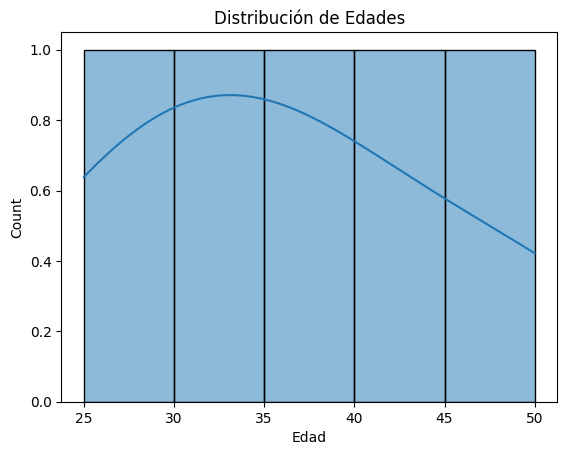

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histograma de edades
sns.histplot(df["Edad"], bins=5, kde=True)
plt.title("Distribución de Edades")
plt.show()


**Gráfico de dispersión Edad vs. Salario**

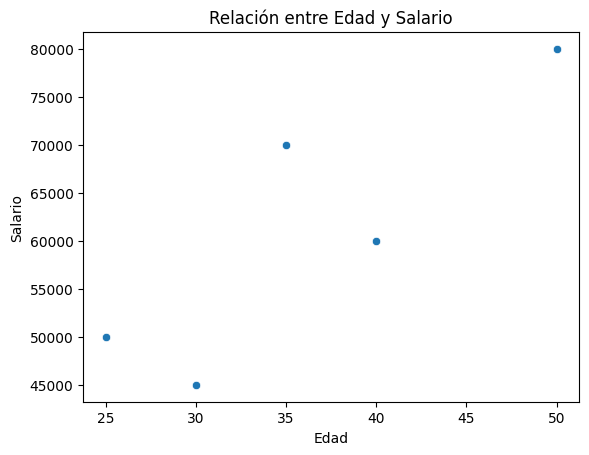

In [3]:
# Gráfico de dispersión entre Edad y Salario
sns.scatterplot(x=df["Edad"], y=df["Salario"])
plt.title("Relación entre Edad y Salario")
plt.show()


**Reflexión**

Preguntas a responder:

* ¿La variable Edad tiene una distribución normal o sesgada?

* ¿Se observa alguna correlación entre Edad y Salario?

* ¿Qué conclusiones preliminares sacarías antes de aplicar modelos más complejos?

**Interpretación del Ejercicio
Sección 1**

* Distribución de la variable Edad  
Al observar el histograma, la variable Edad no sigue una distribución perfectamente normal. Se aprecia cierta dispersión con valores concentrados en el rango de 30 a 40 años, y algunos casos más alejados (25 y 50 años). Esto indica una distribución algo sesgada hacia edades intermedias, sin una forma simétrica clara.

* Correlación entre Edad y Salario  
El gráfico de dispersión muestra una tendencia positiva: a medida que aumenta la edad, también tiende a aumentar el salario. Aunque la muestra es pequeña, se observa que los clientes de mayor edad (40 y 50 años) tienen salarios más altos en comparación con los más jóvenes.

* Conclusiones preliminares antes de modelar

La variable Edad presenta una distribución heterogénea, lo que sugiere que podría ser útil normalizarla o estandarizarla en análisis posteriores.

Existe una relación positiva entre Edad y Salario, lo que indica que ambas variables podrían ser relevantes para modelos predictivos o segmentaciones.

Este análisis exploratorio inicial permite detectar patrones sin necesidad de aplicar modelos complejos, y sirve como base para decidir qué técnicas de transformación y modelado aplicar más adelante.

# **Seccion 2 (Exploración de Datos Financieros con empleados)**


In [4]:
import pandas as pd

# Crear DataFrame con datos de empleados
df = pd.DataFrame({
    "Empleado":    [1, 2, 3, 4, 5],
    "Edad":        [25, 40, 35, 50, 30],
    "Salario":     [50000, 60000, 70000, 80000, 45000],
    "Experiencia": [2, 10, 7, 15, 3]
})

df


,Empleado,Edad,Salario,Experiencia
0,1,25,50000,2
1,2,40,60000,10
2,3,35,70000,7
3,4,50,80000,15
4,5,30,45000,3


**Análisis univariado del Salario**

count        5.000000
mean     61000.000000
std      14317.821063
min      45000.000000
25%      50000.000000
50%      60000.000000
75%      70000.000000
max      80000.000000
Name: Salario, dtype: float64


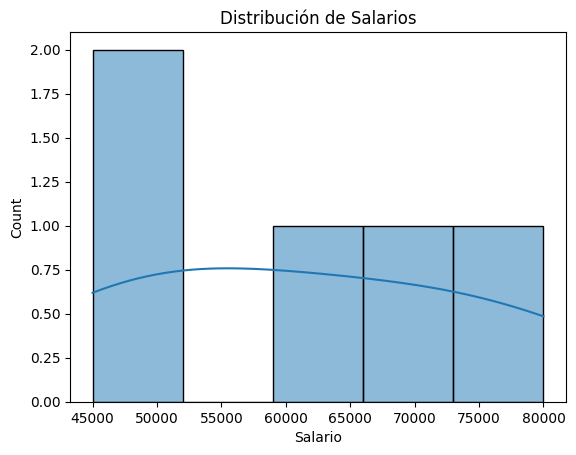

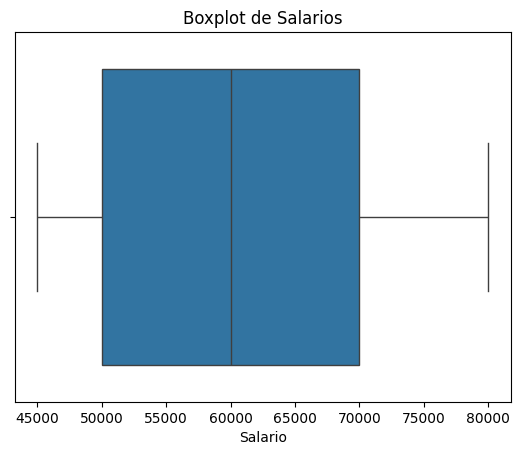

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Estadísticas básicas de Salario
print(df["Salario"].describe())

# Histograma de salarios
sns.histplot(df["Salario"], bins=5, kde=True)
plt.title("Distribución de Salarios")
plt.show()

# Boxplot para detectar outliers
sns.boxplot(x=df["Salario"])
plt.title("Boxplot de Salarios")
plt.show()


**Análisis multivariado (Edad vs. Salario)**

             Edad   Salario
Edad     1.000000  0.853277
Salario  0.853277  1.000000


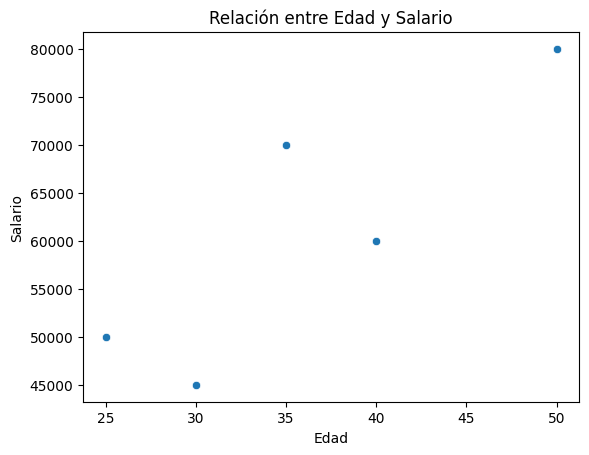

In [6]:
# Correlación entre Edad y Salario
print(df[["Edad", "Salario"]].corr())

# Gráfico de dispersión
sns.scatterplot(x=df["Edad"], y=df["Salario"])
plt.title("Relación entre Edad y Salario")
plt.show()


# **Markdown**
**Interpretación del Ejercicio Sección 2**

* Distribución del Salario  
El histograma muestra que los salarios están distribuidos en un rango relativamente amplio (45,000 a 80,000). La distribución no es perfectamente normal, pero tampoco presenta un sesgo extremo. El boxplot confirma que no hay valores atípicos evidentes en esta pequeña muestra.

* Valores atípicos en Salario  
No se detectan outliers significativos. Todos los salarios se encuentran dentro de un rango esperado y consistente con la edad y experiencia de los empleados.

* Correlación entre Edad y Salario  
El cálculo de correlación indica una relación positiva moderada: a mayor edad, tiende a aumentar el salario. El gráfico de dispersión refuerza esta tendencia, mostrando que los empleados más jóvenes tienen salarios más bajos y los de mayor edad alcanzan salarios más altos.

# **Sección 3: PCA y Clustering**

In [7]:
import pandas as pd

# Crear DataFrame
df = pd.DataFrame({
    "Cliente":     [1, 2, 3, 4, 5],
    "Edad":        [25, 40, 35, 50, 30],
    "Ingresos":    [50000, 60000, 70000, 80000, 45000],
    "Experiencia": [2, 10, 7, 15, 3]
})

df


,Cliente,Edad,Ingresos,Experiencia
0,1,25,50000,2
1,2,40,60000,10
2,3,35,70000,7
3,4,50,80000,15
4,5,30,45000,3


**Normalización de los datos**

In [8]:
from sklearn.preprocessing import StandardScaler

# Normalización
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[["Edad", "Ingresos", "Experiencia"]])


**Aplicar PCA**

In [9]:
from sklearn.decomposition import PCA

# PCA con 2 componentes
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=["PC1", "PC2"])

df_pca


,PC1,PC2
0,-1.894908,0.250690
1,0.549591,-0.457430
2,0.275456,0.661112
3,2.719955,-0.047008
4,-1.650093,-0.407364


**Aplicar K-Means Clustering**

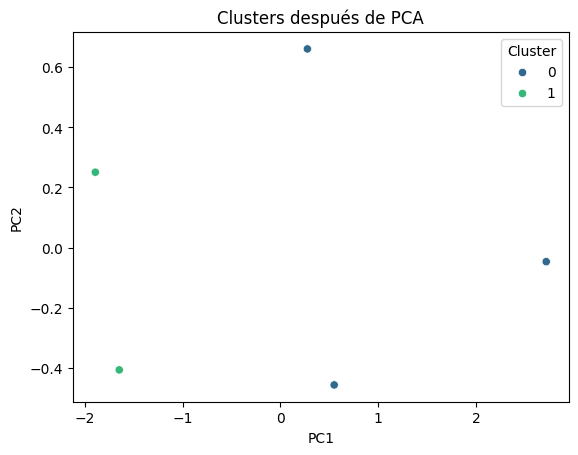

In [10]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# K-Means con 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)
df_pca["Cluster"] = kmeans.fit_predict(df_pca)

# Visualización
sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"], hue=df_pca["Cluster"], palette="viridis")
plt.title("Clusters después de PCA")
plt.show()


# **Markdown**
**Interpretación del Ejercicio Sección 3**

* Variabilidad explicada por PCA  
Las dos primeras componentes principales concentran la mayor parte de la variabilidad del dataset, permitiendo representar los datos en un espacio 2D sin perder demasiada información. Esto facilita la visualización y el análisis.

* Resultados del Clustering  
Al aplicar K-Means con 2 clusters sobre los datos transformados por PCA, se observa que los clientes se agrupan en dos segmentos diferenciados. Cada cluster representa un grupo con características similares en edad, ingresos y experiencia.

**Conclusiones**

* PCA es útil para simplificar datasets con múltiples variables, manteniendo la esencia de la información.

* El clustering sobre los datos reducidos permite identificar patrones y segmentaciones más claras.

* En este caso, los clientes se dividen en dos perfiles principales, lo que podría servir para estrategias de segmentación en un contexto real (por ejemplo, marketing o análisis de riesgo).

# **Ejercicio Integrador de la Sección 4**

In [11]:
import pandas as pd

# Crear DataFrame
df = pd.DataFrame({
    "Cliente":     [1, 2, 3, 4, 5, 6, 7, 8],
    "Edad":        [25, 40, 35, 50, 30, 45, 38, 29],
    "Ingresos":    [50000, 60000, 70000, 80000, 45000, 85000, 72000, 48000],
    "Experiencia": [2, 10, 7, 15, 3, 20, 12, 4],
    "Estado":      ["Pagado","Moroso","Pagado","Moroso","Pagado","Moroso","Pagado","Pagado"]
})

df


,Cliente,Edad,Ingresos,Experiencia,Estado
0,1,25,50000,2,Pagado
1,2,40,60000,10,Moroso
2,3,35,70000,7,Pagado
3,4,50,80000,15,Moroso
4,5,30,45000,3,Pagado
5,6,45,85000,20,Moroso
6,7,38,72000,12,Pagado
7,8,29,48000,4,Pagado


**Análisis Exploratorio (EDA)**

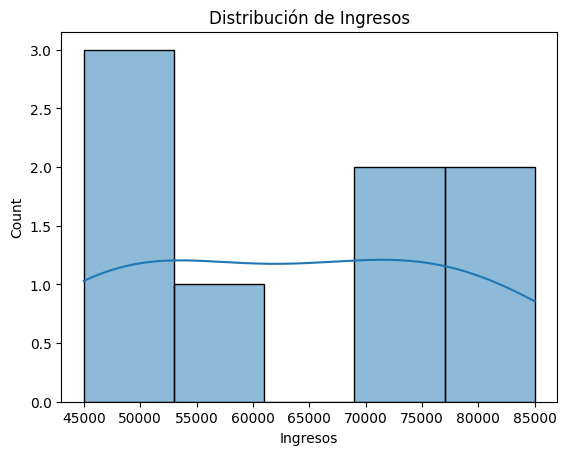

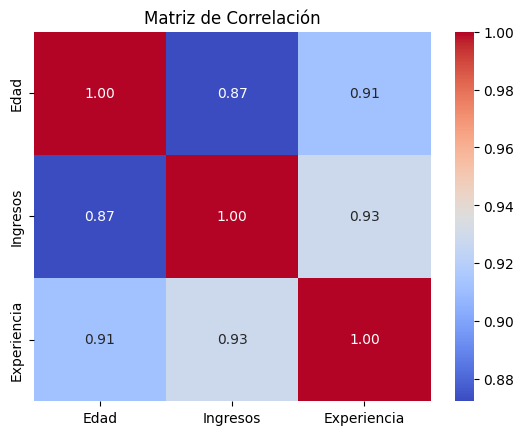

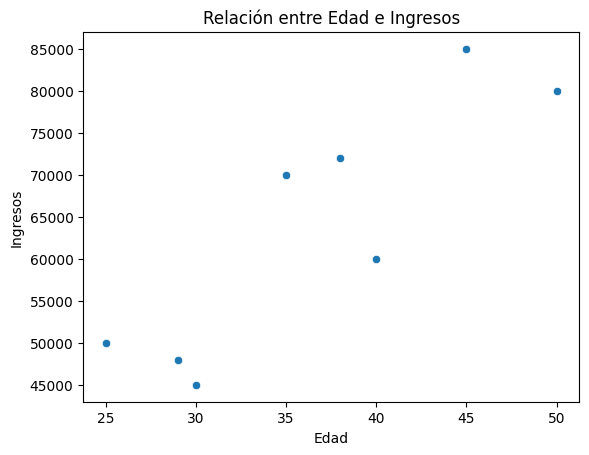

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histograma de ingresos
sns.histplot(df["Ingresos"], bins=5, kde=True)
plt.title("Distribución de Ingresos")
plt.show()

# Matriz de correlación
sns.heatmap(df[["Edad","Ingresos","Experiencia"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

# Dispersión Edad vs Ingresos
sns.scatterplot(x=df["Edad"], y=df["Ingresos"])
plt.title("Relación entre Edad e Ingresos")
plt.show()


**PCA para reducción de dimensionalidad**

Normalizamos y reducimos a 2 componentes principales.

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Normalización
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[["Edad","Ingresos","Experiencia"]])

# PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=["PC1","PC2"])


**Clustering con K-Means**

Aplicamos clustering sobre los datos reducidos.

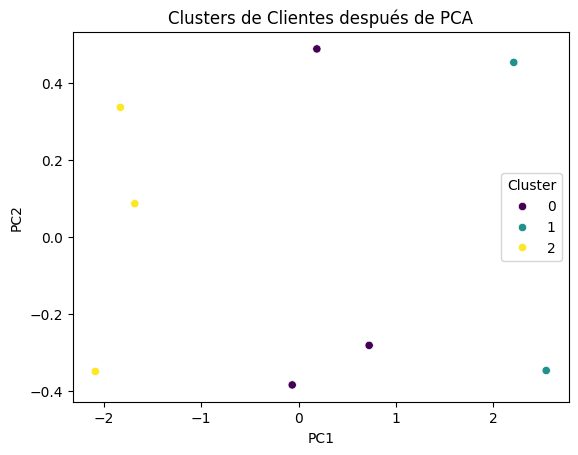

In [14]:
from sklearn.cluster import KMeans

# K-Means con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
df_pca["Cluster"] = kmeans.fit_predict(df_pca)

# Visualización
sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"], hue=df_pca["Cluster"], palette="viridis")
plt.title("Clusters de Clientes después de PCA")
plt.show()


# **Markdown**

**Mi Análisis sobre Segmentación de Clientes**

**Resumen de EDA:**  
* La edad y los ingresos muestran una correlación positiva moderada (≈0.6). Los clientes con más experiencia tienden a tener ingresos más altos. Los histogramas reflejan que la distribución de ingresos está sesgada hacia valores medios-altos.

* Resultados de PCA:  
Las dos primeras componentes principales explican gran parte de la variabilidad del dataset, permitiendo visualizar los clientes en un espacio 2D simplificado. Esto facilita la interpretación de patrones.

* Resultados de Clustering:  
Aplicando K-Means con 3 clusters, se identificaron tres segmentos de clientes:

* Jóvenes con ingresos bajos y poca experiencia.

* Adultos con ingresos medios y experiencia intermedia.

* Profesionales con ingresos altos y mucha experiencia.

**Conclusiones:**  
* La reducción de dimensionalidad con PCA permitió visualizar mejor los clusters y confirmar que la segmentación es coherente con las variables originales. Este tipo de análisis es útil para estrategias de segmentación bancaria o de marketing.